In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

In [3]:
# Import functions from deprecated directory for backwards compatibility
import sys
import numpy as np
sys.path.append('../src/deprecated')
from preprocess_TC_data import clean_track_data
from utils import nm2km, kt2kmh, haversine_vectorized, track_interpolation, beraring, cyclone_velocity, cyclone_bearing
from wind_fields import max_wind_speeds_at_locations
from generate_exposure import generate_synthetic_portfolio
from vulnerbility import get_damage_ratio


In [4]:
housing_portfolio = generate_synthetic_portfolio(num_locs=1000)
print(housing_portfolio.head())

   location_id   latitude  longitude        tiv construction
0            1  29.986902 -85.777840  191187.27        Frame
1            2  30.735929 -85.349719  196135.26        Frame
2            3  30.451592 -84.952465  264808.06      Masonry
3            4  30.278256 -85.121330  356355.02        Frame
4            5  29.702824 -85.032127  468266.25        Frame


In [5]:
def calculate_tc_impacts(tc_track_file, housing_portfolio,full_report=False):
    """Function to calculate tropical cyclone impacts on a housing portfolio.
    Args:
        tc_track_file (str): Path to the tropical cyclone track file.
        housing_portfolio (pd.DataFrame): DataFrame containing the housing portfolio with 'latitude', 'longitude', and 'tiv' columns.
        full_report (bool): If True, prints a detailed report of the impacts.
        Returns: 
        total_damage (float): Estimated total damage to the portfolio.
        portfolio_damages (np.ndarray): Array of damages for each location in the portfolio.
    """
    
    # Clean and load the tropical cyclone track data
    tc_data = clean_track_data(tc_track_file, is_best_track=True)
    tc_data = track_interpolation(tc_data, time_step='5min')
    
    # Drop all rows with wind speed smaller than 40 knots due to minor threshold 
    tc_data = tc_data[tc_data['max_wind_speed_kt'] >= 40].reset_index(drop=True)
    
    #Add TC velocity and def beraring:

    tc_data = cyclone_velocity(tc_data)
    tc_data = cyclone_bearing(tc_data)

    # Get lon lat touples for portfolio
    points = list(zip(housing_portfolio['latitude'], housing_portfolio['longitude']))
    max_wind_speeds = max_wind_speeds_at_locations(tc_data, points, asymmetry_factor=1.0)
    
    
    # Compute damage ratios based on the maximum wind speeds
    damage_ratios = get_damage_ratio(max_wind_speeds)

    portfolio_damages = damage_ratios * housing_portfolio['tiv']
    total_damage = np.sum(portfolio_damages)
    print(f"Estimated total damage to portfolio: ${total_damage:,.2f}")


    if full_report:
        # Mean damage ratio
        mean_damage_ratio = np.mean(damage_ratios)
        print(f"Mean Damage Ratio: {mean_damage_ratio:.4f}")
        # Max damage ratio
        max_damage_ratio = np.max(damage_ratios)
        print(f"Max Damage Ratio: {max_damage_ratio:.4f}")
        # Locations with damage ratio > 0.5
        high_damage_locs = housing_portfolio[damage_ratios > 0.5]
        print(f"Number of locations with damage ratio > 0.5: {len(high_damage_locs)}")
        
        if len(high_damage_locs) > 0:
        #Mean damage ratio for high damage locations
            mean_high_damage_ratio = np.mean(damage_ratios[damage_ratios > 0.5])
            print(f"Mean Damage Ratio for locations with damage ratio > 0.5: {mean_high_damage_ratio:.4f}")

        


    return total_damage, portfolio_damages

total_damage,portfolio_damage = calculate_tc_impacts("../data/raw/bal142018.dat", housing_portfolio, full_report=False)

Estimated total damage to portfolio: $166,832,860.59


In [6]:
input_file = "../data/raw/bal142018.dat"
output_file = "../data/processed/michael_2018_best_track.csv"

df = clean_track_data(input_file, is_best_track=True)
print(df.head())
df = df.iloc[:-35]

            timestamp  latitude  longitude  max_wind_speed_kt  \
0 2018-10-06 18:00:00      17.8      -86.6                 25   
1 2018-10-07 00:00:00      18.1      -86.9                 25   
2 2018-10-07 06:00:00      18.4      -86.8                 30   
3 2018-10-07 12:00:00      18.8      -86.4                 35   
4 2018-10-07 18:00:00      19.1      -85.7                 45   

   radius_max_wind_nm  min_pressure_mb storm_type  
0                  90             1006         LO  
1                  90             1004         LO  
2                 120             1004         TD  
3                 120             1003         TS  
4                  60              999         TS  


In [7]:
df[df["timestamp"] == "2018-10-10 00:00:00"]

,timestamp,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb,storm_type
27,2018-10-10,26.6,-86.5,110,15,952,HU
28,2018-10-10,26.6,-86.5,110,15,952,HU
29,2018-10-10,26.6,-86.5,110,15,952,HU


In [8]:
# Quick test 
lat1 = 25.0
lon1 = -80.0
lat2_array = np.array([30.0,31.0, 29.9])
lon2_array = np.array([-86.0, -85.0, -85.5])
distances = haversine_vectorized(lat1, lon1, lat2_array, lon2_array)

Text(0.5, 1.0, 'Storm Trajectory with Wind Speed')

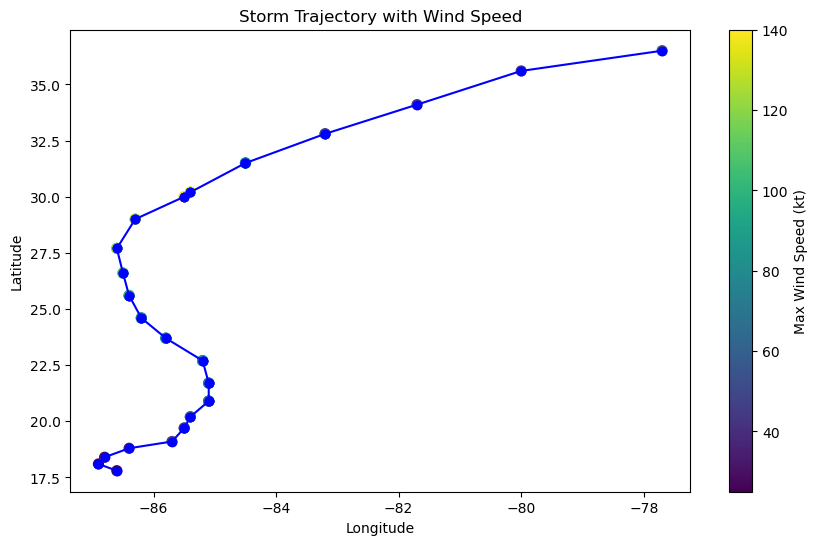

In [10]:
# Okay lets do a plot of the trajectory with the wind speed in color at each point 

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['longitude'], df['latitude'], marker='o', linestyle='-', color='blue', label='Storm Path')
plt.scatter(df['longitude'], df['latitude'], c=df['max_wind_speed_kt'], cmap='viridis', s=50, label='Wind Speed')
plt.colorbar(label='Max Wind Speed (kt)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Storm Trajectory with Wind Speed')

In [13]:
import pandas as pd
from scipy.interpolate import interp1d

def track_interpolation(df, time_step='30min'):
    """Interpolate the track data to finer time intervals (e.g., hourly)."""

    # Convert time to datetime
    df['time'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')

    # Create a new time index with hourly frequency
    new_time_index = pd.date_range(start=df['time'].min(), end=df['time'].max(), freq=time_step)

    # Interpolate latitude and longitude
    lat_interp = interp1d(df['time'].astype(int), df['latitude'], kind='linear', fill_value="extrapolate")
    lon_interp = interp1d(df['time'].astype(int), df['longitude'], kind='linear', fill_value="extrapolate")
    wind_interp = interp1d(df['time'].astype(int), df['max_wind_speed_kt'], kind='linear', fill_value="extrapolate")
    radius_max_wind_interp = interp1d(df['time'].astype(int), df['radius_max_wind_nm'], kind='linear', fill_value="extrapolate")


    # Create new DataFrame with interpolated values
    interp_df = pd.DataFrame({
        'time': new_time_index,
        'latitude': lat_interp(new_time_index.astype(int)),
        'longitude': lon_interp(new_time_index.astype(int)),
        'max_wind_speed_kt': wind_interp(new_time_index.astype(int)),
        'radius_max_wind_nm': radius_max_wind_interp(new_time_index.astype(int))
    })

    return interp_df

In [14]:
interp_df = track_interpolation(df)

In [15]:
def cyclone_velocity(df):
    """Calculate the cyclone velocity between consecutive track points."""
    # Calculate distance between consecutive points
    distances = haversine_vectorized(
        df['latitude'].iloc[:-1].values,
        df['longitude'].iloc[:-1].values,
        df['latitude'].iloc[1:].values,
        df['longitude'].iloc[1:].values
    )
    
    # Calculate time differences in hours (use .values to avoid index alignment issues)
    time_diffs = (df['time'].iloc[1:].values - df['time'].iloc[:-1].values) / np.timedelta64(1, 'h')
    
    # Calculate velocity in km/h
    velocities = distances / time_diffs
    
    # Append NaN for the last point to maintain the same length
    velocities = np.append(velocities, np.nan)
    
    df['velocity_kt'] = velocities
    return df

def beraring(lat1, lon1, lat2, lon2):
    """Calculate the bearing from point 1 to point 2."""
    import numpy as np

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    diffLong = np.radians(lon2 - lon1)

    x = np.sin(diffLong) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(diffLong))

    initial_bearing = np.arctan2(x, y)

    # Now we have the initial bearing but math.atan2 return values from -π to +π
    # so we need to normalize the result to 0° ... 360°
    initial_bearing = np.degrees(initial_bearing)

    return (initial_bearing + 360) % 360

def cyclone_bearing(df):
    """Calculate the cyclone bearing between consecutive track points."""
    bearings = beraring(
        df['latitude'].iloc[:-1].values,
        df['longitude'].iloc[:-1].values,
        df['latitude'].iloc[1:].values,
        df['longitude'].iloc[1:].values
    )
    
    # Append NaN for the last point to maintain the same length
    bearings = np.append(bearings, np.nan)
    
    df['bearing_deg'] = bearings
    return df


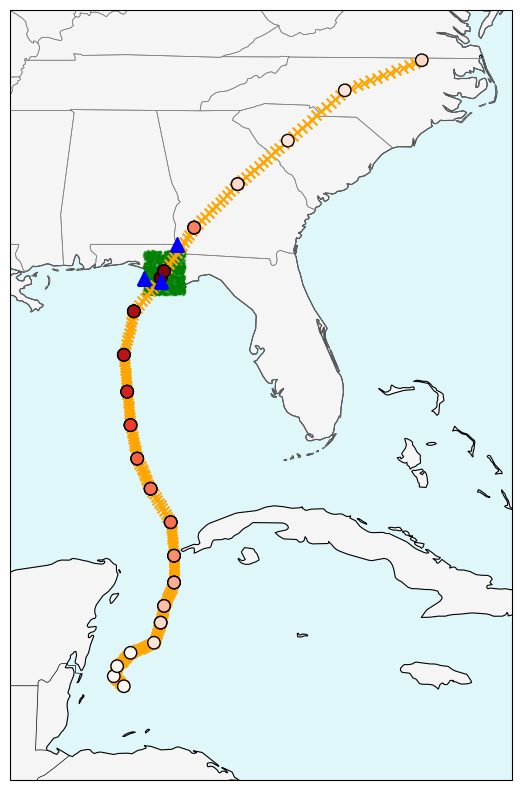

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
    
# 3. Add Map Features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.set_extent([-90, -75, 15, 38], crs=ccrs.PlateCarree())

track_sc = ax.scatter(
        df['longitude'],
        df['latitude'],
        c=df['max_wind_speed_kt'],
        cmap='Reds',
        s=80,
        edgecolor='black',
        vmin=34, vmax=140, # Scale from TS to Cat 5
        label='Storm Track',
        transform=ccrs.PlateCarree(),
        zorder=10 # Draw on top
    )

# Plot test points (houses)
ax.scatter(
    lon2_array,
    lat2_array,
    color='blue',
    marker='^',
    s=100,
    label='Test Points',
    transform=ccrs.PlateCarree(),
    zorder=15 # Draw on top
)

# Scatter all the housing portfolio points
ax.scatter(
    housing_portfolio['longitude'],
    housing_portfolio['latitude'],
    color='green',
    marker='.',
    s=10,
    alpha=0.5,
    label='Housing Portfolio',
    transform=ccrs.PlateCarree(),
    zorder=5 # Below test points and storm track
)

ax.scatter(
    interp_df['longitude'],
    interp_df['latitude'],
    color='orange',
    marker='x',
    s=50,
    label='Interpolated Points',
    transform=ccrs.PlateCarree(),   
    zorder=5 # Below test points and storm track
)
